# Control examples: coupling controllers to the physics

A **controller** is a differentiable dynamical system a cell carries internally: a subclass of
`ODEController`, an abstract **dynamic** step that integrates a per-cell ODE over each macro-step with
an adaptive diffrax solver and returns the change as a sparse state delta. It reads some state fields
(`inputs`) and writes others (`outputs`), and *those outputs are ordinary state fields* - so a
controller that writes `active_speed` feeds `ActiveBrownianDynamics2D`, one that writes `growth_rate`
feeds `SaturatingCellGrowth`, one that writes `division_rate` feeds `Division`. Coupling is by shared
field name, exactly as the physics layers couple to each other; nothing else is needed.

Three concrete controllers ship, differing only in their `vector_field`:

- **`GeneNetworkConnectionist`** - a connectionist gene circuit: a linear regulatory drive
  `sigmoid(g @ W_gene + inputs @ W_in + b)` minus linear degradation.
- **`GeneNetworkMWC`** - a thermodynamic (Monod-Wyman-Changeux) circuit with log-occupancy
  regulation, in the spirit of the *Drosophila* gap-gene analyses.
- **`NeuralODE`** - a generic MLP vector field, for when you would rather learn the dynamics.

Their parameters are given **explicitly** to the constructor (the library does no random
initialization): a `jax.Array` weight is trained, a Python list/tuple is frozen, and an unset one
defaults to zeros. Below we build **four small models** that put a controller in the loop with the
physics:

1. **Active matter** - a cell's motility is throttled by the mechanical stress it feels, and the
   population clusters (motility-induced phase separation).
2. **Patterning** - a morphogen gradient from an organizer drives differential growth, and the tissue
   grows a lobe toward the source.
3. **Homeostasis** - a colony *learns* a two-signal (activator / inhibitor) secretion program, by the
   score-function estimator, so it grows to a target number of cells and stops.
4. **Training** - gradient descent through `simulate` tunes a controller to hit a target morphology.

In [1]:
import jax
import jax.numpy as jnp

# The library is written for float64; enable it before anything touches JAX.
jax.config.update('jax_enable_x64', True)

import numpy as np
import equinox as eqx
import optax
import matplotlib.pyplot as plt

%matplotlib inline

import jax_morph as jxm
from jax_morph.core.state import StateFieldSpec
from jax_morph.control import GeneNetworkConnectionist, GeneNetworkMWC
from jax_morph.physics import (
    Morse,
    SoftSphere,
    MechanicalRelaxation,
    ActiveBrownianDynamics2D,
    ACTIVE_SPEED,
    VirialStress,
    FreeScreenedDiffusion,
    SaturatingCellGrowth,
    GROWTH_RATE,
    Division,
)

key = jax.random.PRNGKey(0)
print('jax-morph', jxm.__version__)

jax-morph 0.4.0


A few helpers - seed a live cluster, pull a frame out of a `history=True` trajectory, and draw
circles coloured by a per-cell value - shared by every scenario below.

In [2]:
def seed(model, positions, *, capacity, radius=0.5, space=None, **cell_fields):
    # Seed the first n slots alive with the given positions/radius; set any extra per-cell fields
    # (a scalar broadcasts to the live cells, an array of shape (n, ...) is written as given).
    positions = jnp.asarray(positions, float)
    n, dim = positions.shape
    builder = jxm.build_state_from_model(model)
    s = builder.init_empty(capacity=capacity, n_space_dim=dim, n_types=1, space=space)
    s = s.update(
        alive=s.alive.at[:n].set(True),
        radius=s.radius.at[:n].set(radius),
        position=s.position.at[:n].set(positions),
        celltype=s.celltype.at[:n, 0].set(1.0),
    )
    for name, val in cell_fields.items():
        s = s.set(name, s[name].at[:n].set(jnp.asarray(val, float)))
    return s


def frame(hist, t):
    # (positions, radii, alive) as numpy arrays for macro-step t of a stacked trajectory.
    return (np.asarray(hist.position[t]), np.asarray(hist.radius[t]), np.asarray(hist.alive[t]))


def frame_state(hist, t):
    return jax.tree_util.tree_map(lambda x: x[t], hist)  # frame t as a full state


def span_limits(hist, pad=0.6):
    # Generous shared limits from the LAST frame's live cells, so a panel series shares one scale.
    pos, rad, alive = frame(hist, -1)
    p = pos[alive.astype(bool)]
    m = float(rad.max()) + pad
    return ((p[:, 0].min() - m, p[:, 0].max() + m), (p[:, 1].min() - m, p[:, 1].max() + m))

## 1. Active matter: motility regulated by stress -> clustering

Self-propelled particles that **slow down where they are crowded** spontaneously phase-separate into
dense clusters and a dilute gas - motility-induced phase separation (Cates and Tailleur). We build
that feedback out of a controller. Each cell:

- feels a mechanical **stress** from a soft repulsion (`VirialStress` writes the per-cell virial
  pressure - high in crowded regions);
- runs a gene circuit that reads `stress` and sets its self-propulsion `active_speed` - a negative
  input weight, so more stress means slower motion;
- self-propels along a persistent, rotationally-diffusing heading (`ActiveBrownianDynamics2D`).

No attraction anywhere: the clustering is purely kinetic, produced by the stress -> speed feedback.
`VirialStress` is quasistatic (schedule slot A); the controller and the active dynamics are dynamic
(slot B), so the mover reads the stress computed at the top of the step.

In [3]:
BOX, N = 24.0, 300
space = jxm.geometry.periodic(BOX)
repulsion = SoftSphere(epsilon=3.0)  # purely repulsive: crowding -> stress, no adhesion

stress_spec = (StateFieldSpec('stress', heritable=False),)  # the field VirialStress writes
motility = GeneNetworkConnectionist(
    stress_spec, (ACTIVE_SPEED,), hidden_size=0,
    W_in=jnp.array([[-8.0]]),  # stress represses speed
    b=jnp.array([1.0]),        # positive baseline drive (fast when unstressed)
    gamma=0.4,
)
mips = jxm.Model([
    VirialStress(repulsion),                                              # A: sense crowding
    motility,                                                             # B: stress -> speed
    ActiveBrownianDynamics2D(repulsion, n_space_dim=2, kT=0.0, rot_diffusion=0.03),  # B: self-propel
])

rng = np.random.default_rng(0)
s0 = jxm.build_state_from_model(mips).init_empty(capacity=N, n_space_dim=2, n_types=1, space=space)
s0 = s0.update(
    alive=s0.alive.at[:].set(True),
    radius=s0.radius.at[:].set(0.5),
    position=s0.position.at[:].set(jnp.asarray(rng.uniform(0, BOX, (N, 2)))),
    celltype=s0.celltype.at[:, 0].set(1.0),
    active_speed=s0.active_speed.at[:].set(2.5),                          # start fast and uniform
    active_heading=s0.active_heading.at[:].set(jnp.asarray(rng.uniform(0, 2 * np.pi, N))),
)
hist = jxm.simulate(mips, s0, n_steps=200, dt=0.1, key=jax.random.PRNGKey(1), history=True)


def local_density(pos, box, rc=2.0):
    # mean number of neighbours within rc (minimum-image), a simple clustering order parameter
    p = np.asarray(pos)
    d = p[:, None, :] - p[None, :, :]
    d -= box * np.round(d / box)
    r = np.sqrt((d ** 2).sum(-1))
    np.fill_diagonal(r, 1e9)
    return (r < rc).sum(1).mean()


dens = np.array([local_density(hist.position[t], BOX) for t in range(hist.position.shape[0])])
print(f'local density {dens[0]:.1f} -> {dens[-1]:.1f} neighbours (clustering)')

local density 6.4 -> 8.9 neighbours (clustering)


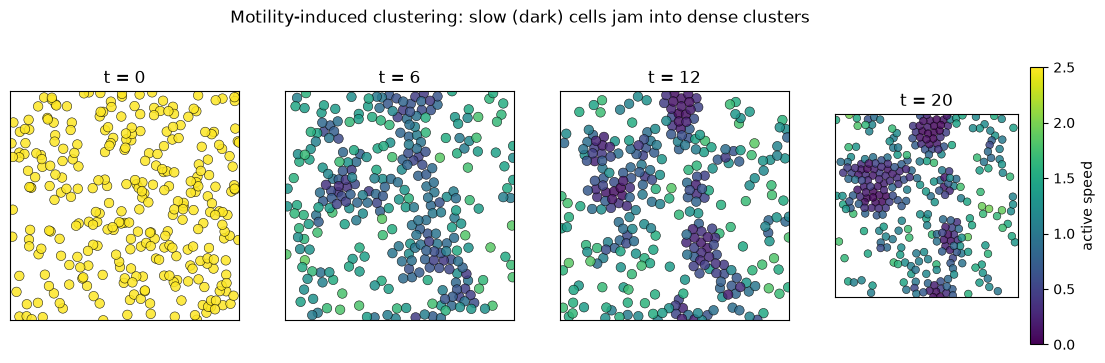

In [4]:
picks = [0, 60, 120, 200]
fig, axes = plt.subplots(1, len(picks), figsize=(3.4 * len(picks), 3.6))
for ax, t in zip(axes, picks):
    st = frame_state(hist, t).set('position', jnp.mod(hist.position[t], BOX))  # periodic view
    jxm.viz.draw(st, ax=ax, color_by='active_speed', cmap='viridis', vlim=(0, 2.5),
                 lims=((0, BOX), (0, BOX)), colorbar=ax is axes[-1], title=f't = {float(hist.t[t]):g}')
fig.axes[-1].set_ylabel('active speed')
fig.suptitle('Motility-induced clustering: slow (dark) cells jam into dense clusters', y=1.04)
plt.show()

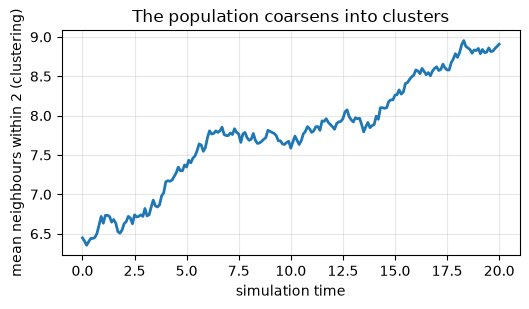

In [5]:
fig, ax = plt.subplots(figsize=(5.4, 3.2))
ax.plot(np.asarray(hist.t), dens, lw=2)
ax.set_xlabel('simulation time')
ax.set_ylabel('mean neighbours within 2 (clustering)')
ax.set_title('The population coarsens into clusters')
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 2. Patterning: a morphogen gradient drives differential growth

A classic developmental motif: a localized **organizer** secretes a morphogen, and cells read their
position from its concentration and grow accordingly (Wolpert's positional information). We wire it
with the thermodynamic `GeneNetworkMWC`, whose log-occupancy input is built for concentration
sensing:

- a few cells on the left are the **organizer** (`secretion_rate > 0`); `FreeScreenedDiffusion` spreads
  a steady, screened morphogen field, high near the organizer and decaying away;
- an MWC gene reads the local morphogen and sets `growth_rate`, with a threshold `K_in` and a strongly
  negative baseline `F0` so only cells bathed in morphogen switch growth on;
- a soft repulsion relaxes the tissue as it grows, so the extra volume pushes outward.

The result is a graded cell size and a **lobe** of tissue bulging toward the organizer - shape from a
diffused signal, with no cell-by-cell instructions.

In [6]:
morphogen = (StateFieldSpec('chemical', shape=(1,), heritable=False),)
readout = GeneNetworkMWC(
    morphogen, (GROWTH_RATE,),
    H_in=jnp.array([[6.0]]),                    # morphogen activates the growth gene
    log_K_in=jnp.log(jnp.array([[0.08]])),      # switches on at a low morphogen concentration
    F0=jnp.array([-5.0]),                        # baseline off: no signal -> (almost) no growth
)
field = FreeScreenedDiffusion(n_field_species=1, n_space_dim=2, diffusion=1.0, degradation=0.6)
patterning = jxm.Model([
    MechanicalRelaxation(SoftSphere(epsilon=4.0), max_steps=800, f_tol=1e-3),  # A: pack (repulsive)
    field,                                                                     # A: morphogen field
    readout,                                                                   # B: sense -> growth
    SaturatingCellGrowth(max_radius=1.0),                                      # B: grow
])

rng = np.random.default_rng(3)
gx, gy = np.meshgrid(np.linspace(-4, 4, 9), np.linspace(-1.2, 1.2, 3))
p0 = np.stack([gx.ravel(), gy.ravel()], axis=1) + rng.normal(0, 0.08, (27, 2))  # a wide patch
secretion = (p0[:, 0] < -3.4).astype(float)[:, None] * 5.0                       # organizer = left edge
s0 = seed(patterning, p0, capacity=len(p0), radius=0.35, secretion_rate=secretion)
hist = jxm.simulate(patterning, s0, n_steps=9, dt=1.0, key=key, history=True)


def morphogen_at(hist, t):
    # recompute the steady field on a frame's cells (positions include growth), for colouring
    st = jax.tree_util.tree_map(lambda z: z[t], hist)
    return np.asarray(field(st, dt=1.0, key=None).chemical)[:, 0]


alive = np.asarray(hist.alive[-1]).astype(bool)
x, rad = np.asarray(hist.position[-1])[alive][:, 0], np.asarray(hist.radius[-1])[alive]
chem = morphogen_at(hist, -1)[alive]
print(f'cell radius: near organizer {rad[x < -2].mean():.2f}, far side {rad[x > 1].mean():.2f}')
print(f'corr(morphogen, radius) = {np.corrcoef(chem, rad)[0, 1]:.2f}')

cell radius: near organizer 1.00, far side 0.42
corr(morphogen, radius) = 0.60


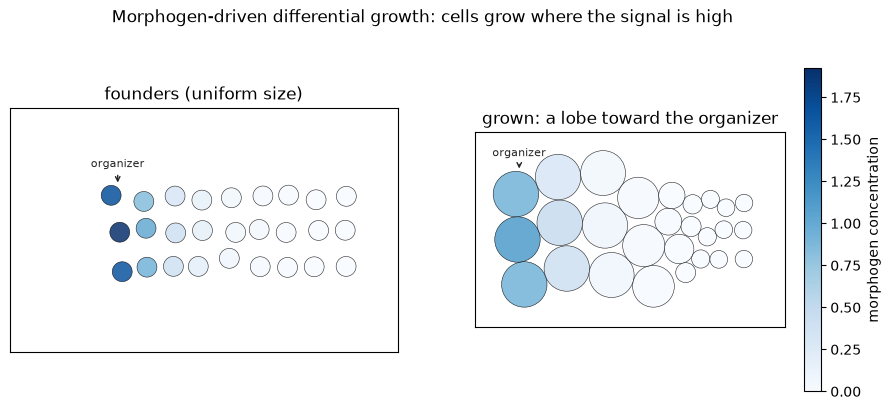

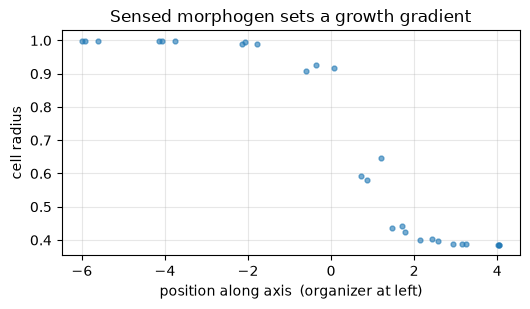

In [7]:
lims = span_limits(hist, pad=0.8)
cmax = float(max(morphogen_at(hist, 0).max(), morphogen_at(hist, -1).max()))


def organizer_mark(hist, t):
    # center-x and top-y of the secreting organizer cells at frame t, so the label tracks them as
    # growth and relaxation push them leftward instead of pinning to the fixed initial boundary.
    st = jax.tree_util.tree_map(lambda z: z[t], hist)
    org = np.asarray(st.alive).astype(bool) & (np.asarray(st.secretion_rate)[:, 0] > 0)
    px, rr = np.asarray(st.position)[org], np.asarray(st.radius)[org]
    return float(px[:, 0].mean()), float((px[:, 1] + rr).max())


fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, t, title in zip(axes, (0, -1), ('founders (uniform size)', 'grown: a lobe toward the organizer')):
    st = frame_state(hist, t)
    jxm.viz.draw(st, ax=ax, color_by=morphogen_at(hist, t), cmap='Blues', vlim=(0, cmax),
                 lims=lims, colorbar=ax is axes[-1], title=title)
    ox, otop = organizer_mark(hist, t)
    ax.annotate('organizer', xy=(ox, otop), xytext=(ox, otop + 0.55), color='0.15', fontsize=8,
                ha='center', va='bottom', arrowprops=dict(arrowstyle='->', color='0.15', lw=1.0))
fig.axes[-1].set_ylabel('morphogen concentration')
fig.suptitle('Morphogen-driven differential growth: cells grow where the signal is high', y=1.02)
plt.show()

fig, ax = plt.subplots(figsize=(5.4, 3.2))
order = np.argsort(x)
ax.plot(x[order], rad[order], '.', ms=7, alpha=0.6)
ax.set_xlabel('position along axis  (organizer at left)')
ax.set_ylabel('cell radius')
ax.set_title('Sensed morphogen sets a growth gradient')
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 3. Homeostasis: learning a secretion program for a target size (score function)

The last two models were hand-wired; this one is **learned**, and it needs the library's *other*
optimization primitive. A colony controls its own size with two diffusible signals - a **short-range
activator** and a **long-range inhibitor** (a classic size-control motif). Every cell secretes both;
one `FreeScreenedDiffusion` step spreads the two species with different screening lengths; and a small
custom step sets the division rate to `sigmoid(activator - inhibitor)` - divide where the activator
wins, stop where the long-range inhibitor has accumulated. As the colony grows the inhibitor builds up
faster (more cells fall inside its long range), so proliferation **self-limits**.

We **learn the two secretion levels** so the colony halts near a **target of 20 cells**. The objective
is the final **cell count** - which is *not differentiable*: a division either happens or it does not
(`alive` is a hard flag), so the pathwise gradient of scenario 4 is identically zero here. Instead we
use the **score-function** estimator (REINFORCE) through **`trajectory_logp`**, which scores the stochastic
division draws and needs no differentiable reward: sample a batch of colonies, reward each by how close
its count is to 20, and make the better outcomes' divisions more likely. Two choices make the gradient
usable - the division sigmoid is the **algebraic** one (heavy tails, so a barely-dividing colony still
has a gradient), and the secretion is set in a **quasistatic** step *before* diffusion, so it shapes
that same macro-step's divisions (a dynamic controller writing it *after* the division rate is fixed
would get no score gradient at all).

The training code keeps the estimator boundary explicit: `simulate` first samples a detached batch
from the current model; only then does the inner surrogate call `trajectory_logp` with the model live.
Sampling is outside `eqx.filter_grad`, so the cell-count reward cannot accidentally contribute a
straight-through gradient. The histories are scored before the optimizer changes the model, making
each update on-policy.

In [8]:
from jax_morph.physics import DIVISION_RATE

SECRETION = StateFieldSpec('secretion_rate', shape=(2,))          # [activator, inhibitor]
CHEM = (StateFieldSpec('chemical', shape=(2,), heritable=False),)


def algebraic_sigmoid(x):
    return 0.5 + 0.5 * x / jnp.sqrt(1.0 + x * x)  # heavy 1/|x| tails -> a gradient survives in the tails


class SecretionProgram(jxm.SimulationStep):
    '''Quasistatic: set the two (learnable) secretion levels for every cell, before diffusion runs.'''

    step_type = jxm.StepType.QUASISTATIC
    raw: jax.Array  # (2,); secretion = softplus(raw) >= 0, and being a jax.Array it is the trained leaf

    def state_writes(self):
        return (SECRETION,)

    def __call__(self, state, *, dt, key):
        levels = jax.nn.softplus(self.raw)
        return state.set('secretion_rate', jnp.broadcast_to(levels, (state.n_cells, 2)))


class MorphogenDivision(jxm.SimulationStep):
    '''Quasistatic: division_rate = algebraic_sigmoid(activator - inhibitor).'''

    step_type = jxm.StepType.QUASISTATIC
    gain: float = 1.0

    def state_reads(self):
        return CHEM

    def state_writes(self):
        return (DIVISION_RATE,)

    def __call__(self, state, *, dt, key):
        c = state.chemical
        return state.set('division_rate', algebraic_sigmoid(self.gain * (c[:, 0] - c[:, 1])))


# One model, declared once: the only jax.Array leaf is SecretionProgram.raw, so it is the only thing
# trained. Every physics constant is a Python float or list - a frozen (static) leaf - including the
# diffusion `degradation`, passed as a list so it is not mistaken for a trainable array.
CAP, N_MACRO, TARGET = 44, 18, 20.0
# secretion = softplus(raw); start under-secreting the activator so the colony stalls small
model = jxm.Model([
    SecretionProgram(raw=jnp.array([4.0, 2.0])),                                     # A: set secretion
    MechanicalRelaxation(Morse(epsilon=1.0, alpha=3.0), max_steps=300, f_tol=1e-1),  # A: pack (weak adhesion)
    FreeScreenedDiffusion(n_field_species=2, n_space_dim=2, diffusion=1.0,
                          degradation=[6.0, 0.08]),                                   # short + long range
    MorphogenDivision(),                                                             # A: rate from signals
    SaturatingCellGrowth(max_radius=0.6),                                            # B: grow
    Division(n_space_dim=2),                                                         # C: divide
])
founders = np.array([[0.0, 0.0], [1.0, 0.1], [0.5, 0.9], [-0.4, 0.7]])
base = seed(model, founders, capacity=CAP, radius=0.5, growth_rate=0.5)


def rollout(m, k):
    return jxm.simulate(m, base, n_steps=N_MACRO, dt=1.0, key=k, history=True)


counts_before = np.asarray(rollout(model, key).alive.sum(1))
print(f'untrained secretion: {int(counts_before[0])} -> {int(counts_before[-1])} cells '
      f'(stalls short of the target {int(TARGET)})')

untrained secretion: 4 -> 7 cells (stalls short of the target 20)


In [9]:
# REINFORCE: sample colonies (detached), then differentiate their trajectory score - the score-
# function estimator for the non-differentiable cell-count reward. filter_grad differentiates the whole
# model but reaches only its one inexact-array leaf, SecretionProgram.raw; filter selects the same leaf
# for the optimizer, so training moves the secretion levels and nothing else.
@eqx.filter_jit
def reinforce_grad(m, keys, baseline):
    hists = jax.lax.stop_gradient(jax.vmap(lambda k: rollout(m, k))(keys))  # a detached batch
    counts = hists.alive[:, -1, :].sum(-1)
    rewards = -((counts - TARGET) ** 2)                        # reward: closeness to the target count

    def surrogate(m):  # joint division log-probability with a live carry across macro-steps
        score = lambda hist: jxm.trajectory_logp(m, hist, 1.0).sum()
        return -jnp.mean((rewards - baseline) * jax.vmap(score)(hists))

    return eqx.filter_grad(surrogate)(m), counts, rewards.mean()


trained = model
optimizer = optax.adam(0.15)
opt_state = optimizer.init(eqx.filter(trained, eqx.is_inexact_array))
baseline, rkey, curve = -200.0, jax.random.PRNGKey(7), []
for epoch in range(50):
    rkey, sub = jax.random.split(rkey)
    grads, counts, reward_mean = reinforce_grad(trained, jax.random.split(sub, 16), baseline)
    baseline = 0.8 * baseline + 0.2 * float(reward_mean)  # EMA baseline (does not collapse to 0)
    updates, opt_state = optimizer.update(grads, opt_state)
    trained = eqx.apply_updates(trained, updates)
    curve.append(float(counts.mean()))

levels = jax.nn.softplus(trained.steps[0].raw)  # the trained SecretionProgram is the first step
print(f'learned secretion: activator {float(levels[0]):.1f}, inhibitor {float(levels[1]):.1f}')
print(f'batch mean count {curve[0]:.0f} -> {curve[-1]:.0f}  (target {int(TARGET)})')

learned secretion: activator 5.3, inhibitor 1.3
batch mean count 9 -> 19  (target 20)


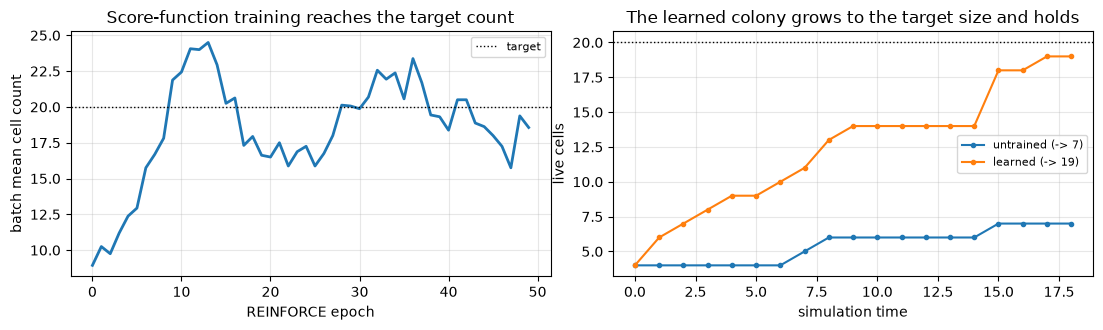

In [10]:
counts_after = np.asarray(rollout(trained, key).alive.sum(1))
time = np.arange(N_MACRO + 1) * 1.0  # dt = 1, so a macro-step advances physical time by 1

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot(curve, lw=2)
axes[0].axhline(TARGET, color='k', ls=':', lw=1, label='target')
axes[0].set_xlabel('REINFORCE epoch')
axes[0].set_ylabel('batch mean cell count')
axes[0].set_title('Score-function training reaches the target count')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)
axes[1].plot(time, counts_before, 'o-', ms=3,  # history includes the t=0 founders frame
             label=f'untrained (-> {int(counts_before[-1])})')
axes[1].plot(time, counts_after, 'o-', ms=3,
             label=f'learned (-> {int(counts_after[-1])})')
axes[1].axhline(TARGET, color='k', ls=':', lw=1)
axes[1].set_xlabel('simulation time')
axes[1].set_ylabel('live cells')
axes[1].set_title('The learned colony grows to the target size and holds')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()

### How the colony knows when to stop

The size control is legible in the two morphogen fields. The **activator** is short-range (screening
length below a cell radius), so every cell essentially sees only its own source - roughly uniform across
the colony. The **inhibitor** is long-range, so it *sums* over the whole colony and piles up in the
interior. The division rate `sigmoid(activator - inhibitor)` is therefore high at the free rim and low
in the crowded core; and as the colony grows the inhibitor rises everywhere until even the rim drops
below threshold and proliferation stops - a self-limiting size.

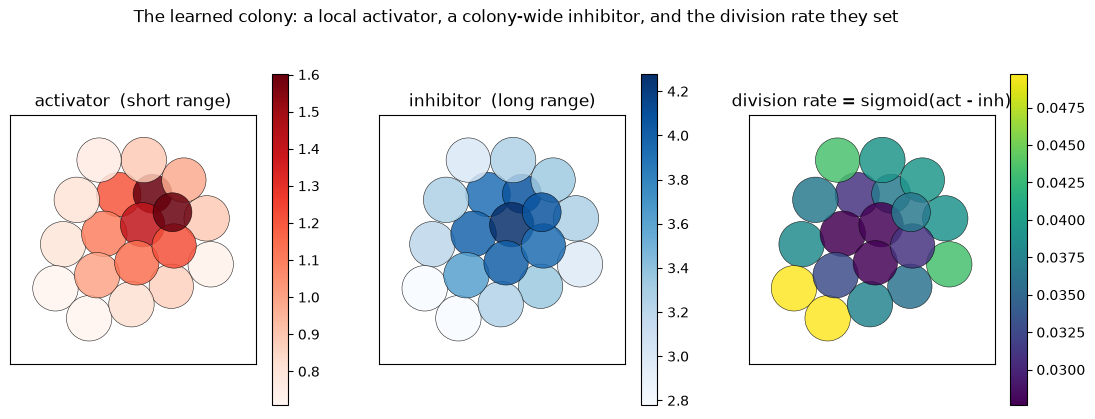

In [11]:
# recompute the two morphogen fields on a state (the diffusion step only, no relaxation)
morphogens = FreeScreenedDiffusion(n_field_species=2, n_space_dim=2, diffusion=1.0,
                                   degradation=[6.0, 0.08])


def fields(state):
    chem = np.asarray(morphogens(state, dt=1.0, key=None).chemical)  # (n, 2): [activator, inhibitor]
    net = chem[:, 0] - chem[:, 1]
    return chem[:, 0], chem[:, 1], 0.5 + 0.5 * net / np.sqrt(1.0 + net ** 2)  # act, inh, division rate


traj = rollout(trained, key)
final = jax.tree_util.tree_map(lambda x: x[-1], traj)
act, inh, rate = fields(final)
lims = span_limits(traj)
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.3))
for ax, v, title, cmap in [(axes[0], act, 'activator  (short range)', 'Reds'),
                           (axes[1], inh, 'inhibitor  (long range)', 'Blues'),
                           (axes[2], rate, 'division rate = sigmoid(act - inh)', 'viridis')]:
    jxm.viz.draw(final, ax=ax, color_by=v, cmap=cmap, lims=lims, colorbar=True, title=title)
fig.suptitle('The learned colony: a local activator, a colony-wide inhibitor, and the division rate they set',
             y=1.03)
plt.show()

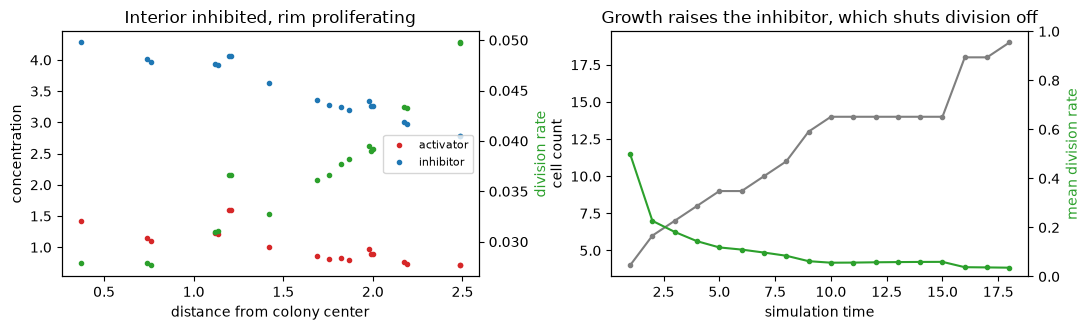

In [12]:
# quantitative: the radial structure, and why growth self-limits over time
alive = np.asarray(final.alive).astype(bool)
xy = np.asarray(final.position)[alive]
r = np.linalg.norm(xy - xy.mean(0), axis=1)
order = np.argsort(r)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot(r[order], act[alive][order], '.', ms=6, color='tab:red', label='activator')
axes[0].plot(r[order], inh[alive][order], '.', ms=6, color='tab:blue', label='inhibitor')
rate_axis = axes[0].twinx()
rate_axis.plot(r[order], rate[alive][order], '.', ms=6, color='tab:green')
rate_axis.set_ylabel('division rate', color='tab:green')  # auto-scaled: the rim-vs-core trend is small
axes[0].set_xlabel('distance from colony center')
axes[0].set_ylabel('concentration')
axes[0].set_title('Interior inhibited, rim proliferating')
axes[0].legend(fontsize=8, loc='center right')

count_t, rate_t = [], []
for t in range(N_MACRO):
    st = jax.tree_util.tree_map(lambda x: x[t], traj)
    a = np.asarray(st.alive).astype(bool)
    _, _, rt = fields(st)
    count_t.append(int(a.sum()))
    rate_t.append(float(rt[a].mean()))
tt = np.arange(1, N_MACRO + 1)
axes[1].plot(tt, count_t, 'o-', ms=3, color='tab:gray', label='cell count')
rate_time_axis = axes[1].twinx()
rate_time_axis.plot(tt, rate_t, 'o-', ms=3, color='tab:green')
rate_time_axis.set_ylabel('mean division rate', color='tab:green')
rate_time_axis.set_ylim(0, 1)
axes[1].set_xlabel('simulation time')
axes[1].set_ylabel('cell count')
axes[1].set_title('Growth raises the inhibitor, which shuts division off')
fig.tight_layout()
plt.show()

## 4. Training a controller against a target morphology

The controllers are differentiable, so a model can be *fit*. `simulate` is pathwise differentiable -
a gradient flows from any objective on the final state back through the growth **and the mechanical
relaxation** (via its implicit-function-theorem equilibrium gradients) to the controller's parameters.
We grow a small colony under a controller that reads a constant cue and sets `growth_rate`, and tune
the controller by Adam (`optax`) so the packed cluster hits a target **gyration radius**.

Unlike the preceding REINFORCE example, this differentiable objective deliberately keeps `simulate`
inside `loss`: the final geometry is the path through which the controller receives its gradient.

We deliberately **freeze the input mixing matrix** by passing `W_in` as a Python list rather than an
array: a non-array field is a static leaf, so it is held fixed while `W_gene`, `b` (the internal
circuit) are trained. Passing a `jax.Array` instead would train it too - the type is the switch. The
circuit is a small chain: the cue enters a single **input gene** (mixing weight 1), a **hidden gene**
relays, and `growth_rate` is read from the **output gene**. Only the internal gene-gene connections
`W_gene` (and the biases) are trained, so training must wire a path from the input to the output; we
look at the colony and those connections before and after.

In [13]:
cue = (StateFieldSpec('chemical', shape=(1,), heritable=False),)


def make_model(bias):
    # One model per starting bias: a 3-gene controller (the cue enters a single INPUT gene at mixing
    # weight 1, a HIDDEN gene relays, growth is read from the OUTPUT gene) plus the physics. Its frozen
    # leaves are Python types - W_in a list (the sensory mixing matrix), gamma a float, and every
    # physics constant a float; its trainable leaves are jax arrays - W_gene (defaulting to zeros) and
    # the biases b. So optimizing the whole model trains exactly W_gene and b and leaves the mixing
    # column and the physics untouched: the type is the only switch.
    controller = GeneNetworkConnectionist(cue, (GROWTH_RATE,), hidden_size=2,
                                          W_in=[[1.0], [0.0], [0.0]], b=jnp.full((3,), bias), gamma=0.5)
    return jxm.Model([
        controller,                                                                     # cue -> growth
        MechanicalRelaxation(Morse(epsilon=2.0, alpha=2.8), max_steps=800, f_tol=1e-3),  # pack
        SaturatingCellGrowth(max_radius=0.6),                                            # grow
    ])


grid = np.stack(np.meshgrid(np.arange(3), np.arange(3)), -1).reshape(-1, 2).astype(float) * 1.1
start = make_model(-3.0)  # an under-growing controller (a small colony) to start from
base = seed(start, grid, capacity=len(grid), radius=0.3)
base = base.set('chemical', base.chemical.at[:].set(jnp.array([1.0])))  # a constant cue to read


def gyration(final):
    a = final.alive.astype(final.radius.dtype)
    com = (final.position * a[:, None]).sum(0) / a.sum()
    return jnp.sqrt((((final.position - com) ** 2).sum(-1) * a).sum() / a.sum())


def rollout(m):
    return jxm.simulate(m, base, n_steps=8, dt=1.0, key=key)


# target a mid-range packed size (between the two reachable extremes)
lo = float(gyration(rollout(make_model(-5.0))))
hi = float(gyration(rollout(make_model(5.0))))
TARGET = 0.5 * (lo + hi)


def loss(m):
    return (gyration(rollout(m)) - TARGET) ** 2


print(f'gyration radius reachable in [{lo:.2f}, {hi:.2f}]; target {TARGET:.2f}')
print(f'start: gyration {float(gyration(rollout(start))):.2f}, loss {float(loss(start)):.4f}')

gyration radius reachable in [0.61, 1.30]; target 0.95
start: gyration 0.76, loss 0.0387


W_in (a list) receives 0 gradient array(s) -> frozen;  W_gene trained? True;  b trained? True


loss 0.0387 -> 9.24e-06


final gyration = 0.96  (target 0.95)
mixing matrix W_in unchanged by training: True


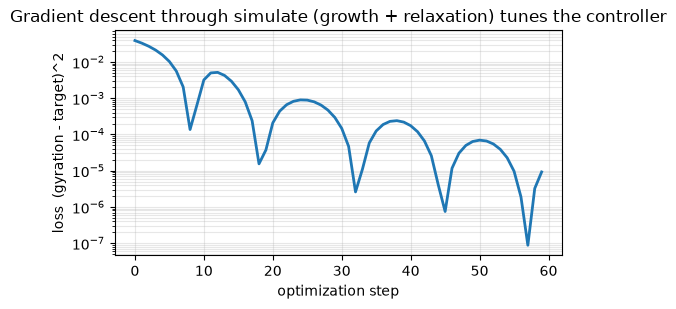

In [14]:
grad_fn = eqx.filter_jit(eqx.filter_value_and_grad(loss))  # compile once, reuse across the loop
cgrads = grad_fn(start)[1].steps[0]  # the controller's slice of the model gradient (the first step)
w_in_grads = [g for g in jax.tree_util.tree_leaves(cgrads.W_in) if eqx.is_array(g)]
print(f'W_in (a list) receives {len(w_in_grads)} gradient array(s) -> frozen;  '
      f'W_gene trained? {cgrads.W_gene is not None};  b trained? {cgrads.b is not None}')

optimizer = optax.adam(0.1)
trained = start
opt_state = optimizer.init(eqx.filter(trained, eqx.is_inexact_array))
losses = []
for step in range(60):
    ell, grads = grad_fn(trained)
    updates, opt_state = optimizer.update(grads, opt_state)
    trained = eqx.apply_updates(trained, updates)
    losses.append(float(ell))

print(f'loss {losses[0]:.4f} -> {losses[-1]:.2e}')
print(f'final gyration = {float(gyration(rollout(trained))):.2f}  (target {TARGET:.2f})')
print(f'mixing matrix W_in unchanged by training: {trained.steps[0].W_in == start.steps[0].W_in}')

fig, ax = plt.subplots(figsize=(5.4, 3.2))
ax.semilogy(losses, lw=2)
ax.set_xlabel('optimization step')
ax.set_ylabel('loss  (gyration - target)^2')
ax.set_title('Gradient descent through simulate (growth + relaxation) tunes the controller')
ax.grid(alpha=0.3, which='both')
fig.tight_layout()
plt.show()

The optimization changes both the **morphology** (the packed colony grows from the under-target start
to the target size) and the **controller** (the gene-gene connections `W_gene`, blank at the start,
are wired up; the frozen mixing column is untouched).

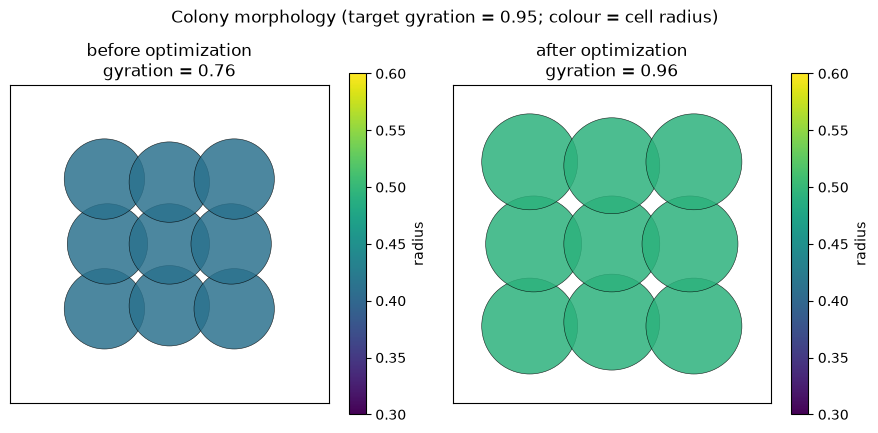

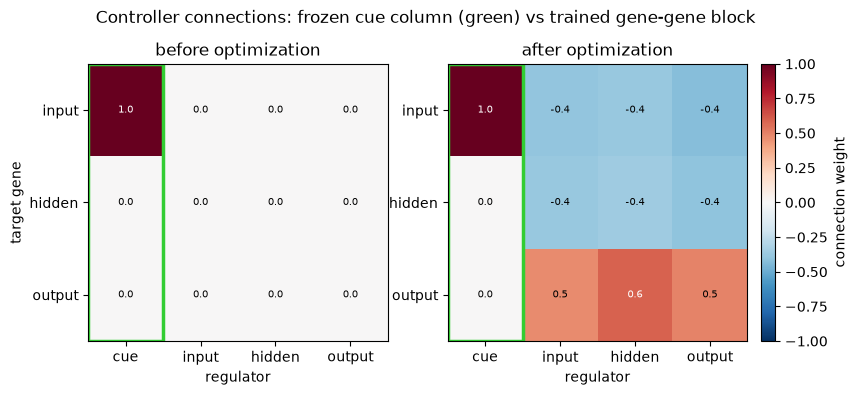

In [15]:
before, after = rollout(start), rollout(trained)  # final states of the start vs trained model

# --- morphology: the packed colony before vs after optimization ---
pos_a = np.asarray(after.position)[np.asarray(after.alive).astype(bool)]
m = float(np.asarray(after.radius).max()) + 0.3
clims = ((pos_a[:, 0].min() - m, pos_a[:, 0].max() + m), (pos_a[:, 1].min() - m, pos_a[:, 1].max() + m))
fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
for ax, f, title in zip(axes, (before, after), ('before optimization', 'after optimization')):
    jxm.viz.draw(f, ax=ax, color_by='radius', cmap='viridis', vlim=(0.3, 0.6), lims=clims,
                 title=f'{title}\ngyration = {float(gyration(f)):.2f}')
fig.suptitle(f'Colony morphology (target gyration = {TARGET:.2f}; colour = cell radius)', y=1.02)
fig.tight_layout()
plt.show()

# --- connections: the regulatory weight matrix [W_in | W_gene] before vs after ---
def weights(ctrl):
    # (3, 4): rows = target gene (input, hidden, output); col 0 = frozen cue (W_in), cols 1-3 = W_gene
    return np.asarray(jnp.concatenate([jnp.asarray(ctrl.W_in), jnp.asarray(ctrl.W_gene)], axis=1))

W0, W1 = weights(start.steps[0]), weights(trained.steps[0])  # the controller is each model's first step
vmax = float(np.abs(np.concatenate([W0, W1])).max())
cols, rows = ['cue', 'input', 'hidden', 'output'], ['input', 'hidden', 'output']
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
for ax, W, title in zip(axes, (W0, W1), ('before optimization', 'after optimization')):
    im = ax.imshow(W, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_xticks(range(4), cols)
    ax.set_yticks(range(3), rows)
    ax.set_xlabel('regulator')
    ax.set_title(title)
    for i in range(3):
        for j in range(4):
            ax.text(j, i, f'{W[i, j]:.1f}', ha='center', va='center', fontsize=7,
                    color='k' if abs(W[i, j]) < 0.55 * vmax else 'w')
    ax.add_patch(plt.Rectangle((-0.5, -0.5), 1, 3, fill=False, edgecolor='limegreen', lw=2.5))
axes[0].set_ylabel('target gene')
fig.colorbar(im, ax=axes, fraction=0.035, pad=0.02, label='connection weight')
fig.suptitle('Controller connections: frozen cue column (green) vs trained gene-gene block', y=1.03)
plt.show()